In [1]:
import pandas as pd
from pathlib import Path


def col_to_index(col: str) -> int:
    """Wandelt Excel-Spaltenbezeichnung (z.B. 'BE', 'ZY') in 0-basierten Index um."""
    col = col.upper()
    result = 0
    for c in col:
        result = result * 26 + (ord(c) - ord('A') + 1)
    return result - 1


# Spaltenranges definieren
RANGES = {
    "Ergebnisse der Fragebögen": ("BE", "BM"),
    "Aktuelle Prophylaxe-Medikamente": ("ZY", "AKY"),
}

for csv_file in Path("patienten-visiten").glob("*.csv"):
    print(f"\n{'=' * 60}")
    print(f"Datei: {csv_file.name}")
    print('=' * 60)

    df = pd.read_csv(csv_file, nrows=0, sep=";")  # nur Header laden
    headers = list(df.columns)

    for bereich, (start_col, end_col) in RANGES.items():
        start_idx = col_to_index(start_col)
        end_idx = col_to_index(end_col)

        # Nur Spalten nehmen, die im DataFrame vorhanden sind
        cols_in_range = headers[start_idx: end_idx + 1]

        print(f"\n📋 {bereich} (Spalten {start_col}–{end_col}):")
        if cols_in_range:
            for i, col in enumerate(cols_in_range, start=start_idx + 1):
                # Spaltennummer als Excel-Buchstabe berechnen
                excel_col = ""
                n = i
                while n > 0:
                    n, rem = divmod(n - 1, 26)
                    excel_col = chr(65 + rem) + excel_col
                print(f"  {excel_col:>4}: {col}")
        else:
            print("  (keine Spalten in diesem Bereich gefunden)")


Datei: Patients_V10_02-03-2026.csv

📋 Ergebnisse der Fragebögen (Spalten BE–BM):
    BE: dass_depression_K10
    BF: dass_fear_K10
    BG: dass_stress_K10
    BH: midas_result_K10
    BI: vr12_msc_K10
    BJ: vr12_psc_K10
    BK: gvas_result_K10
    BL: pgic_result_K10
    BM: chiq_result_K10

📋 Aktuelle Prophylaxe-Medikamente (Spalten ZY–AKY):
    ZY: number_prophy_K10
    ZZ: preventive_name_p1_K10
   AAA: dosage_p1_K10
   AAB: dosage_other_p1_K10
   AAC: dosage_unknown_p1_K10
   AAD: count_p1_K10
   AAE: intake_schema_morning_p1_K10
   AAF: intake_schema_noon_p1_K10
   AAG: intake_schema_evening_p1_K10
   AAH: intake_schema_second_day_p1_K10
   AAI: intake_schema_other_p1_K10
   AAJ: intake_schema_unknown_p1_K10
   AAK: special_intake_schema_id_p1_K10
   AAL: begin_p1_K10
   AAM: effect_p1_K10
   AAN: tolerability_p1_K10
   AAO: satisfaction_p1_K10
   AAP: adherence_p1_K10
   AAQ: number_adverse_p1_K10
   AAR: gase_sum_all_p1_K10
   AAS: gase_sum_off_p1_K10
   AAT: adverse1_p1_K10


In [2]:
import pandas as pd
from pathlib import Path

files = sorted(Path("./patienten-visiten").glob("Patients_V*_02-03-2026.csv"))
len(files), files[:3]

(24,
 [WindowsPath('patienten-visiten/Patients_V10_02-03-2026.csv'),
  WindowsPath('patienten-visiten/Patients_V11_02-03-2026.csv'),
  WindowsPath('patienten-visiten/Patients_V12_02-03-2026.csv')])

In [3]:
def extract_questionnaire_cols(columns):
    keys = [
        "id_patient",
        "dass_depression",
        "dass_fear",
        "dass_stress",
        "midas_result",
        "vr12_msc",
        "vr12_psc",
        "gvas_result",
        "pgic_result",
        "chiq_result"
    ]
    return [c for c in columns if any(k in c for k in keys)]

In [4]:
def extract_prophylaxe_cols(columns):
    keys = [
        "id_patient",
        "number_prophy",
        "preventive_name",
        "dosage",
        "intake_schema",
        "special_intake_schema",
        "begin",
        "effect",
        "tolerability",
        "satisfaction",
        "adherence",
        "number_adverse",
        "gase_",
        "adverse",
        "acute_name_a1_"
    ]
    return [c for c in columns if any(k in c for k in keys)]

In [5]:
def process_file(file_path):
    df = pd.read_csv(
        file_path,
        engine="python",  # robuster Parser
        sep=";"
    )

    cols = df.columns

    questionnaire_cols = extract_questionnaire_cols(cols)
    prophylaxe_cols = extract_prophylaxe_cols(cols)

    questionnaire_df = df[questionnaire_cols].copy()
    prophylaxe_df = df[prophylaxe_cols].copy()

    return questionnaire_df, prophylaxe_df

In [6]:
questionnaire_all = {}
prophylaxe_all = {}

for f in files:
    q_df, p_df = process_file(f)

    key = f.stem
    questionnaire_all[key] = q_df
    prophylaxe_all[key] = p_df

len(questionnaire_all), len(prophylaxe_all)

(24, 24)

In [7]:
def filter_prophylaxe_df(df):
    # preventive_name
    # acute_name_a1_
    keep_keys = [
        "id_patient",
        "acute_name_a1_",
    ]

    cols = df.columns
    selected = [c for c in cols if any(k in c for k in keep_keys)]

    return df[selected].copy()

In [8]:
prophylaxe_filtered = {}

for k, df in prophylaxe_all.items():
    prophylaxe_filtered[k] = filter_prophylaxe_df(df)

len(prophylaxe_filtered)

24

In [9]:
def extract_med_list(df):
    # preventive_name
    # acute_name_a1_
    med_cols = [c for c in df.columns if "acute_name_a1_" in c]

    meds = df[med_cols].values.flatten()

    meds = [
        m for m in meds
        if pd.notna(m)
           and str(m).strip() != ""
           and str(m).strip() != "0"
    ]

    return set(meds)

In [10]:
med_history = {}

for file_name, df in prophylaxe_all.items():

    if "id_patient" not in df.columns:
        continue

    for pid, subdf in df.groupby("id_patient"):
        meds = extract_med_list(subdf)

        med_history.setdefault(pid, {})[file_name] = meds

In [11]:
import re


def get_visit_number(name):
    match = re.search(r"V(\d+)", name)
    return int(match.group(1)) if match else float("inf")

In [12]:
med_events = []

for pid, timeline in med_history.items():

    visits = sorted(timeline.keys(), key=get_visit_number)

    for i in range(1, len(visits)):

        prev_visit = visits[i - 1]
        curr_visit = visits[i]

        prev_meds = timeline[prev_visit]
        curr_meds = timeline[curr_visit]

        started = curr_meds - prev_meds
        stopped = prev_meds - curr_meds

        if not started and not stopped:
            continue


        change_visit = curr_visit

        effect_from = curr_visit

        effect_to = visits[i + 1] if i + 1 < len(visits) else None

        med_events.append({
            "patient": pid,

            "change_from": prev_visit,
            "change_to": curr_visit,

            "effect_from": effect_from,
            "effect_to": effect_to,

            "started": list(started),
            "stopped": list(stopped),

            "event_visit": change_visit
        })

In [13]:
med_events_df = pd.DataFrame(med_events)
med_events_df.head()

,patient,change_from,change_to,effect_from,effect_to,started,stopped,event_visit
0,10614987,Patients_V1_02-03-2026,Patients_V3_02-03-2026,Patients_V3_02-03-2026,Patients_V4_02-03-2026,[Paracetamol],[Metamizol],Patients_V3_02-03-2026
1,10614987,Patients_V3_02-03-2026,Patients_V4_02-03-2026,Patients_V4_02-03-2026,Patients_V5_02-03-2026,[Ibuprofen],[Paracetamol],Patients_V4_02-03-2026
2,10614987,Patients_V10_02-03-2026,Patients_V11_02-03-2026,Patients_V11_02-03-2026,Patients_Vlast_02-03-2026,[Naproxen],[Ibuprofen],Patients_V11_02-03-2026
3,10840708,Patients_V6_02-03-2026,Patients_V7_02-03-2026,Patients_V7_02-03-2026,Patients_V8_02-03-2026,[Rizatriptan],[Naratriptan],Patients_V7_02-03-2026
4,10840708,Patients_V7_02-03-2026,Patients_V8_02-03-2026,Patients_V8_02-03-2026,Patients_V9_02-03-2026,[Naratriptan],[Rizatriptan],Patients_V8_02-03-2026


In [14]:
questionnaire_by_visit = {}

for visit_name, df in questionnaire_all.items():
    if "id_patient" not in df.columns:
        continue

    questionnaire_by_visit[visit_name] = df.set_index("id_patient")

In [15]:
def compute_outcome_delta(pid, v_from, v_to):
    fb_from = questionnaire_by_visit[v_from].loc[pid]
    fb_to = questionnaire_by_visit[v_to].loc[pid]

    diff = fb_to - fb_from

    return diff

In [16]:
import pandas as pd


def get_value(df, pid, key_part):
    cols = [c for c in df.columns if key_part in c]
    if not cols:
        return None

    val = df.loc[pid, cols[0]]

    if pd.isna(val):
        return None

    if isinstance(val, str):
        val = val.replace(",", ".")

    val = pd.to_numeric(val, errors="coerce")

    if pd.isna(val):
        return None

    return float(val)

In [17]:
def safe_delta(fb_from, fb_to, pid, key):
    a = get_value(fb_from, pid, key)
    b = get_value(fb_to, pid, key)

    if a is None or b is None:
        return None

    return b - a

In [18]:
enriched_events = []

for row in med_events_df.to_dict("records"):

    pid = row["patient"]
    v_from = row["effect_from"]
    v_to = row["effect_to"]

    if v_from not in questionnaire_by_visit or v_to not in questionnaire_by_visit:
        continue

    fb_from = questionnaire_by_visit[v_from]
    fb_to = questionnaire_by_visit[v_to]

    if pid not in fb_from.index or pid not in fb_to.index:
        continue

    enriched_events.append({
        **row,

        "dass_depression_delta": safe_delta(fb_from, fb_to, pid, "dass_depression"),
        "dass_fear_delta": safe_delta(fb_from, fb_to, pid, "dass_fear"),
        "dass_stress_delta": safe_delta(fb_from, fb_to, pid, "dass_stress"),

        "midas_delta": safe_delta(fb_from, fb_to, pid, "midas_result"),
        "vr12_msc_delta": safe_delta(fb_from, fb_to, pid, "vr12_msc"),
        "vr12_psc_delta": safe_delta(fb_from, fb_to, pid, "vr12_psc"),

        "gvas_delta": safe_delta(fb_from, fb_to, pid, "gvas_result"),
        "pgic_delta": safe_delta(fb_from, fb_to, pid, "pgic_result"),
        "chiq_delta": safe_delta(fb_from, fb_to, pid, "chiq_result"),
    })

In [19]:
med_outcome_df = pd.DataFrame(enriched_events)
med_outcome_df.head()

,patient,change_from,change_to,effect_from,effect_to,started,stopped,event_visit,dass_depression_delta,dass_fear_delta,dass_stress_delta,midas_delta,vr12_msc_delta,vr12_psc_delta,gvas_delta,pgic_delta,chiq_delta
0,10614987,Patients_V1_02-03-2026,Patients_V3_02-03-2026,Patients_V3_02-03-2026,Patients_V4_02-03-2026,[Paracetamol],[Metamizol],Patients_V3_02-03-2026,-2.0,-1.0,2.0,4.0,-9.365798,-3.456817,-33.0,3.0,NaN
1,10614987,Patients_V3_02-03-2026,Patients_V4_02-03-2026,Patients_V4_02-03-2026,Patients_V5_02-03-2026,[Ibuprofen],[Paracetamol],Patients_V4_02-03-2026,1.0,0.0,2.0,6.0,11.084407,-5.912443,13.0,0.0,NaN
2,10614987,Patients_V10_02-03-2026,Patients_V11_02-03-2026,Patients_V11_02-03-2026,Patients_Vlast_02-03-2026,[Naproxen],[Ibuprofen],Patients_V11_02-03-2026,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,NaN
3,10840708,Patients_V6_02-03-2026,Patients_V7_02-03-2026,Patients_V7_02-03-2026,Patients_V8_02-03-2026,[Rizatriptan],[Naratriptan],Patients_V7_02-03-2026,-1.0,-1.0,1.0,10.0,1.372666,4.051208,10.0,-3.0,NaN
4,10840708,Patients_V7_02-03-2026,Patients_V8_02-03-2026,Patients_V8_02-03-2026,Patients_V9_02-03-2026,[Naratriptan],[Rizatriptan],Patients_V8_02-03-2026,0.0,0.0,-1.0,-17.0,-0.616306,1.853853,-1.0,-1.0,NaN


In [20]:
import numpy as np


def patient_stats(df, col):
    vals = df[col].dropna().values
    if len(vals) < 3:
        return None, None

    return np.mean(vals), np.std(vals)

In [21]:
def is_patient_outlier(value, mean, std):
    if std is None or std == 0 or np.isnan(std):
        return False
    return abs(value - mean) > 1.2 * std

In [22]:
scores = [
    "dass_depression_delta",
    "dass_fear_delta",
    "dass_stress_delta",
    "midas_delta",
    "vr12_msc_delta",
    "vr12_psc_delta",
    "gvas_delta",
    "pgic_delta",
    "chiq_delta"
]

events = []

for pid, sub in med_outcome_df.groupby("patient"):

    for score in scores:

        if score not in sub.columns:
            continue

        mean, std = patient_stats(sub, score)

        if mean is None:
            continue

        for row in sub.to_dict("records"):

            val = row[score]

            if val is None or np.isnan(val):
                continue

            if is_patient_outlier(val, mean, std):
                events.append({
                    "patient": pid,
                    "from_visit": row["effect_from"],
                    "to_visit": row["effect_to"],
                    "med_started": row["started"],
                    "med_stopped": row["stopped"],
                    "score": score,
                    "value": val,
                    "mean_patient": mean,
                    "std_patient": std,
                    "z_like": (val - mean) / std if std else None
                })

In [23]:
import pandas as pd

events_df = pd.DataFrame(events)
events_df

,patient,from_visit,to_visit,med_started,med_stopped,score,value,mean_patient,std_patient,z_like
0,10322677,Patients_V7_02-03-2026,Patients_V8_02-03-2026,[Eletriptan],[Naproxen],dass_depression_delta,2.000000,1.000000,0.816497,1.224745
1,10322677,Patients_V8_02-03-2026,Patients_Vlast_02-03-2026,[Naproxen],[Eletriptan],dass_depression_delta,0.000000,1.000000,0.816497,-1.224745
2,10322677,Patients_V3_02-03-2026,Patients_V4_02-03-2026,[Naproxen],[Eletriptan],dass_fear_delta,4.000000,0.666667,2.494438,1.336306
3,10322677,Patients_V8_02-03-2026,Patients_Vlast_02-03-2026,[Naproxen],[Eletriptan],dass_stress_delta,0.000000,1.666667,1.247219,-1.336306
4,10322677,Patients_V3_02-03-2026,Patients_V4_02-03-2026,[Naproxen],[Eletriptan],midas_delta,11.000000,3.000000,5.715476,1.399708
...,...,...,...,...,...,...,...,...,...,...
2587,99470837,Patients_V5_02-03-2026,Patients_V8_02-03-2026,[Sumatriptan],[Naratriptan],vr12_msc_delta,9.488063,2.615476,4.905648,1.400954
2588,99470837,Patients_V5_02-03-2026,Patients_V8_02-03-2026,[Sumatriptan],[Naratriptan],vr12_psc_delta,7.445748,1.287032,4.594182,1.340547
2589,99470837,Patients_V5_02-03-2026,Patients_V8_02-03-2026,[Sumatriptan],[Naratriptan],gvas_delta,25.000000,8.666667,11.556624,1.413331
2590,99470837,Patients_V12_02-03-2026,Patients_V13_02-03-2026,[Naratriptan],[Sumatriptan],pgic_delta,-2.000000,-1.000000,0.816497,-1.224745


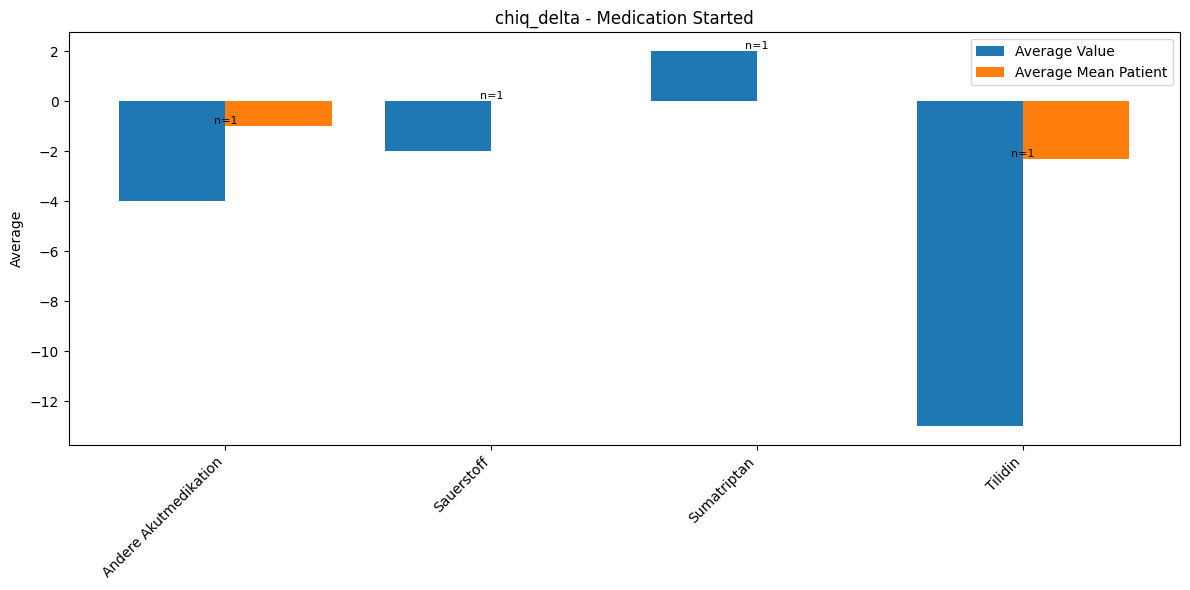

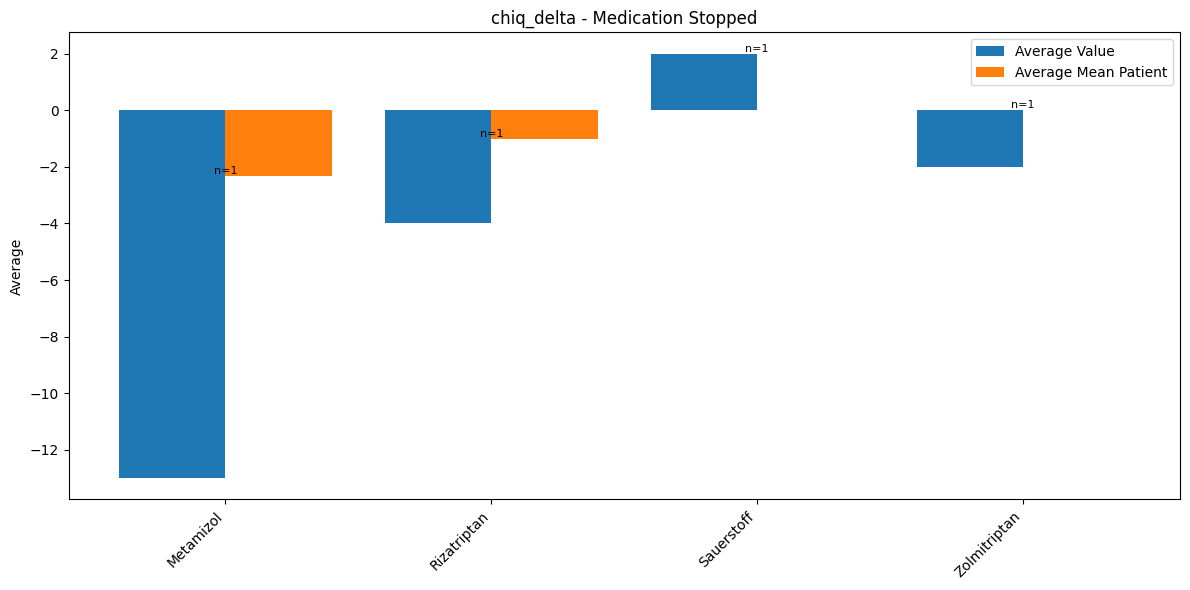

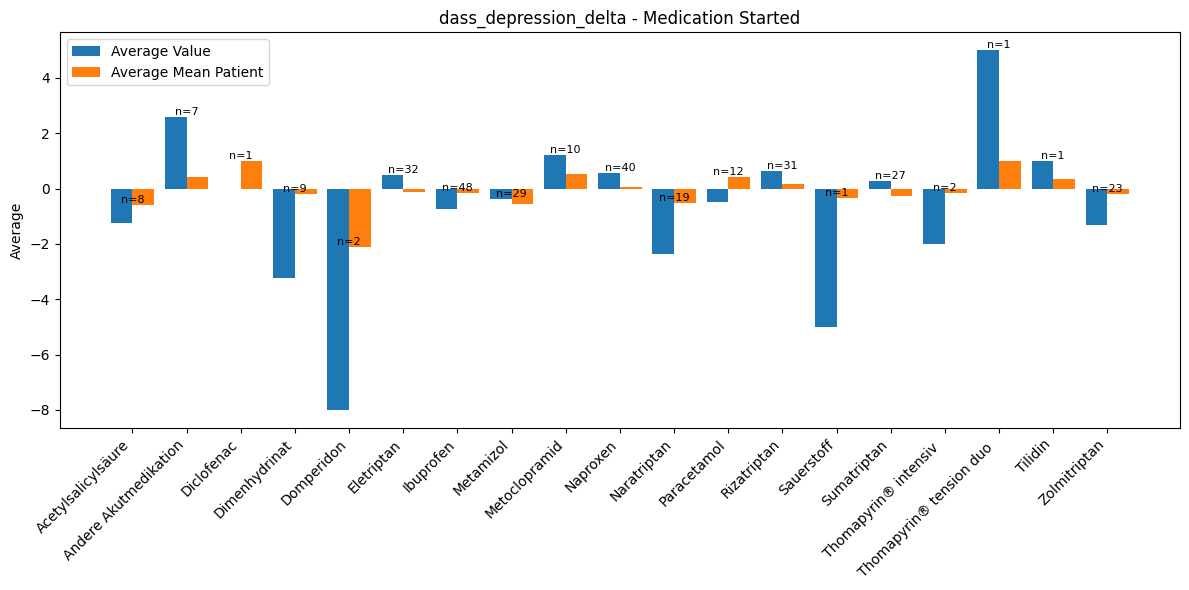

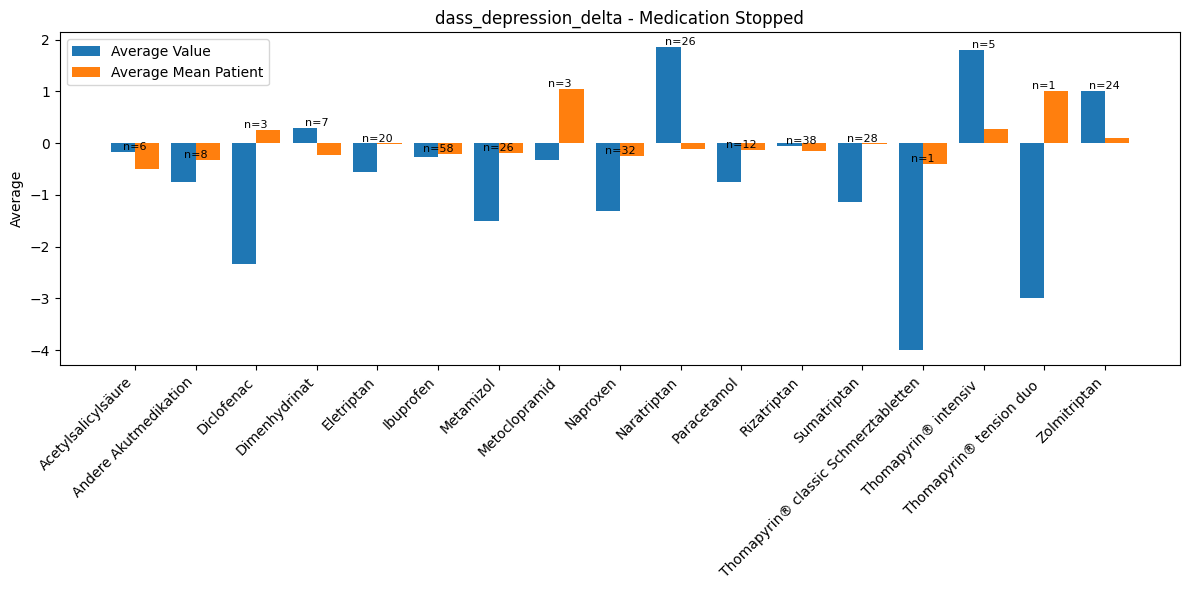

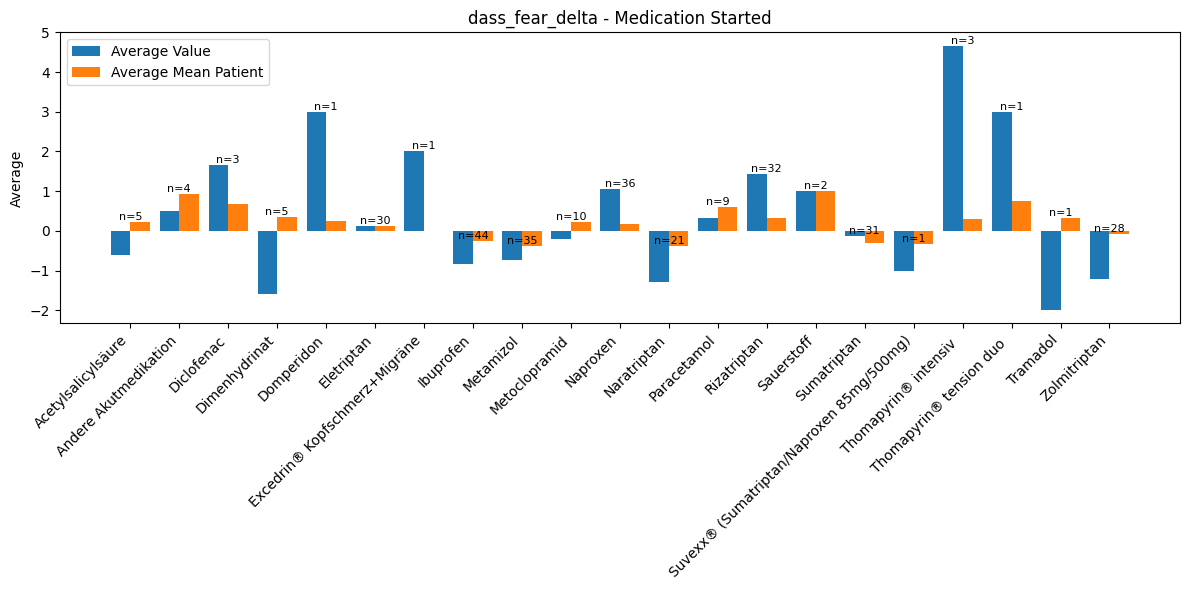

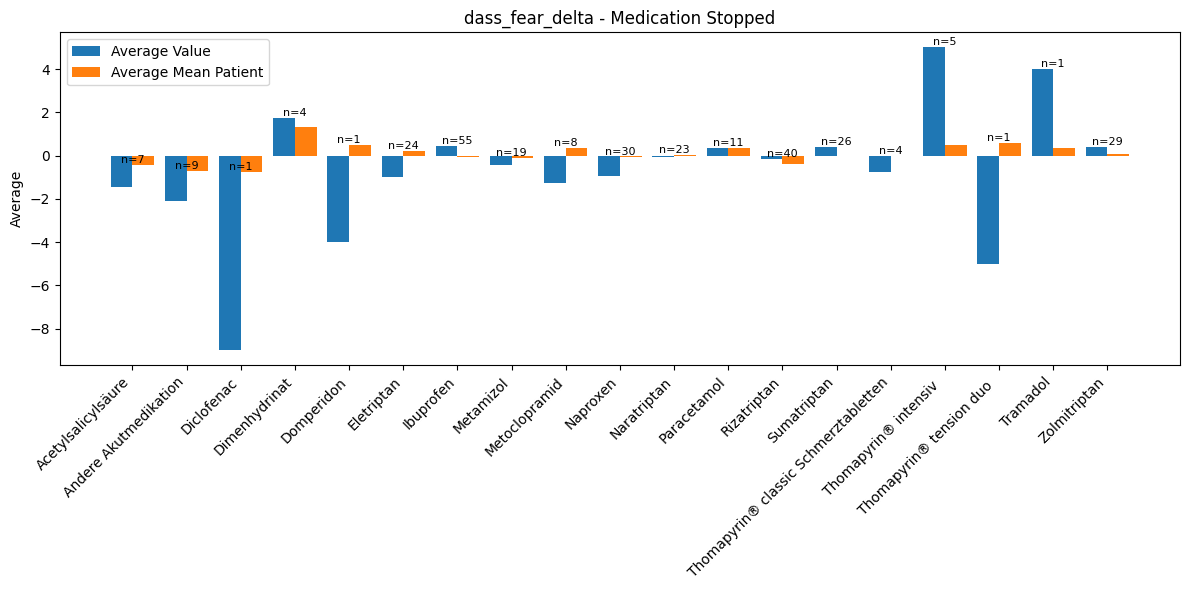

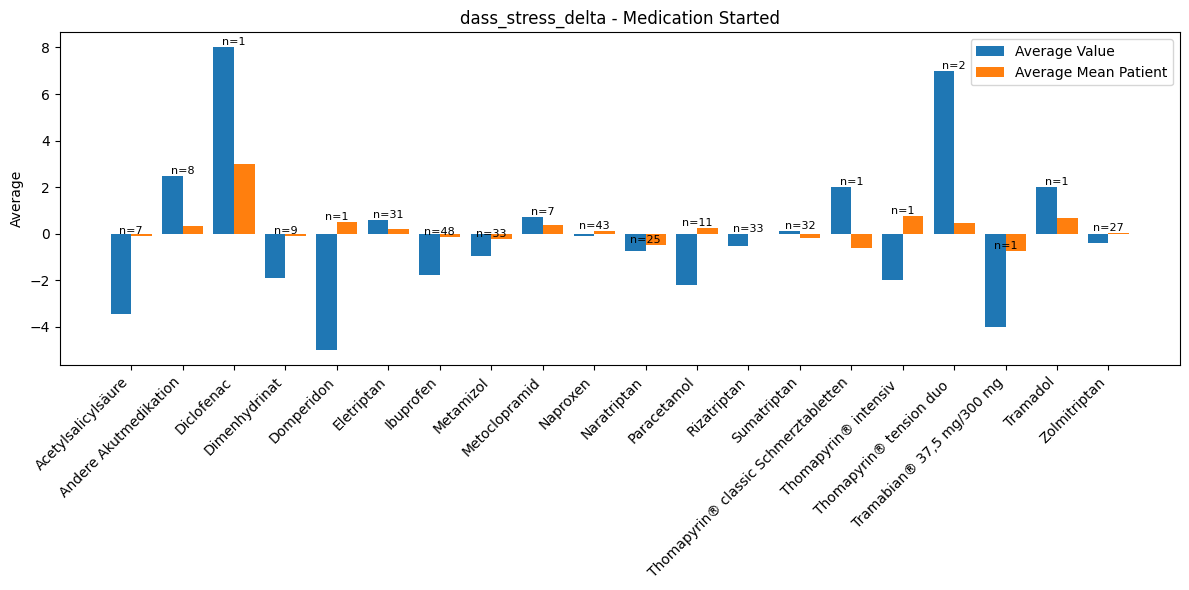

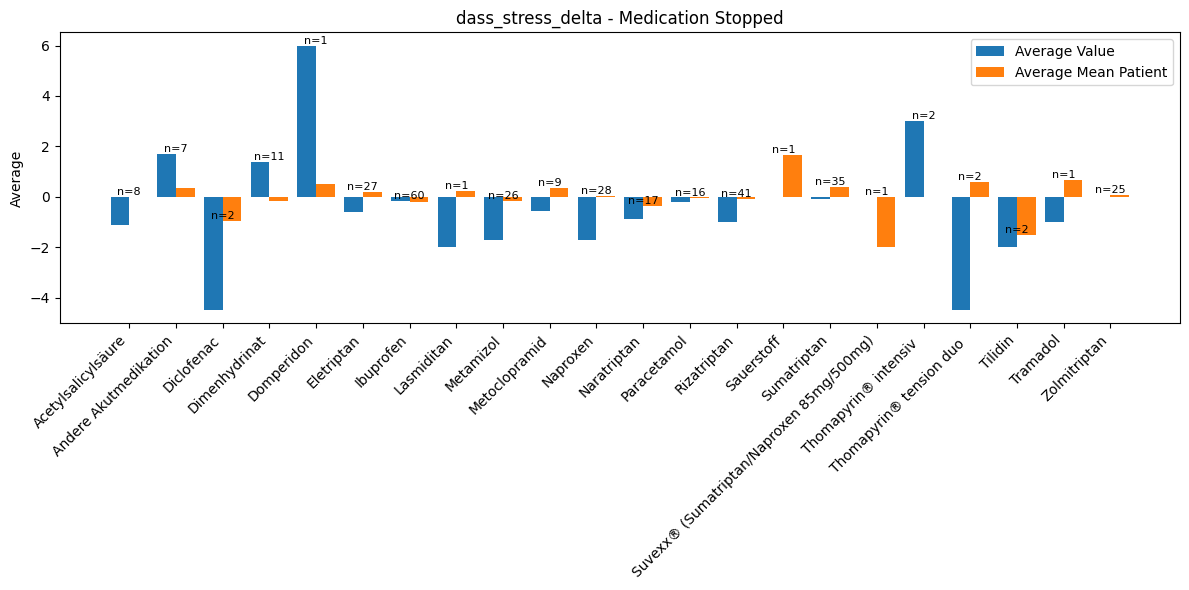

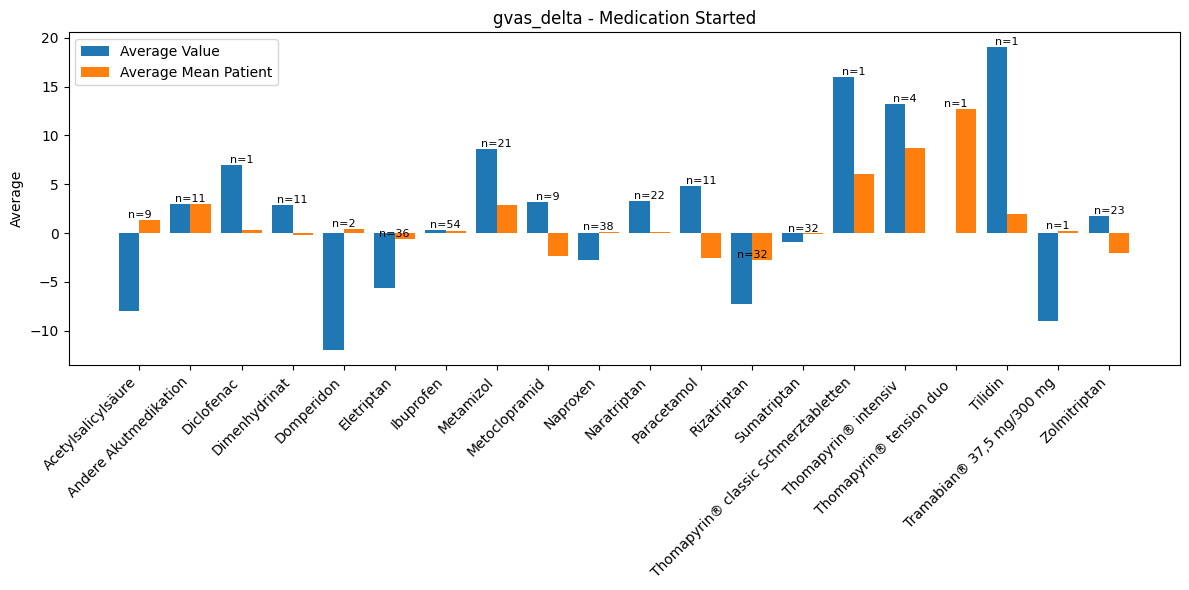

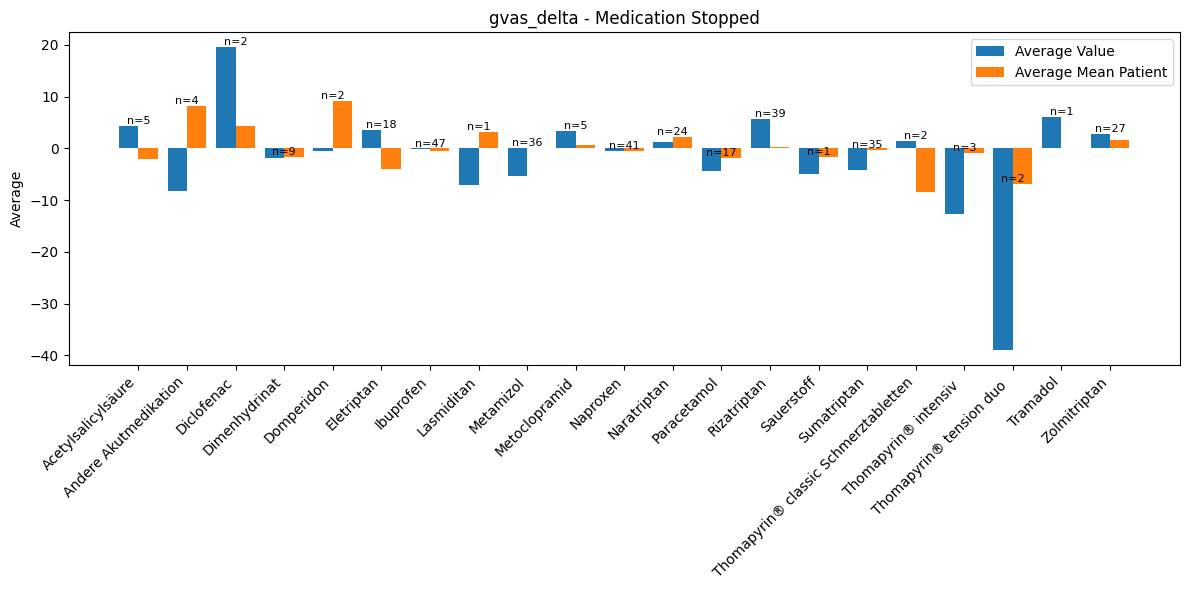

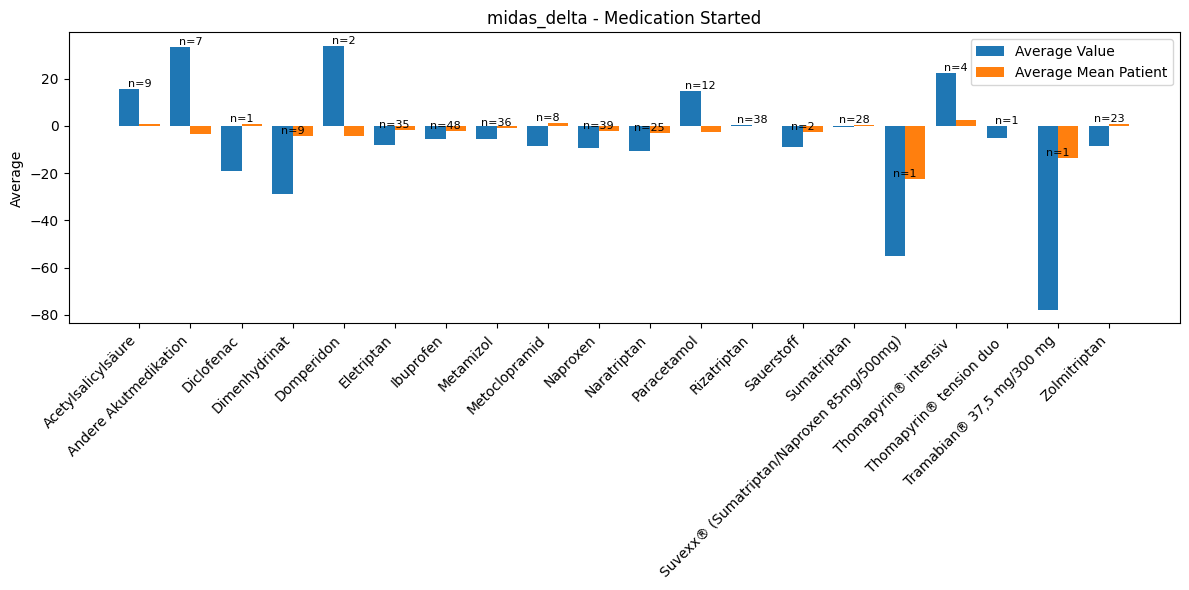

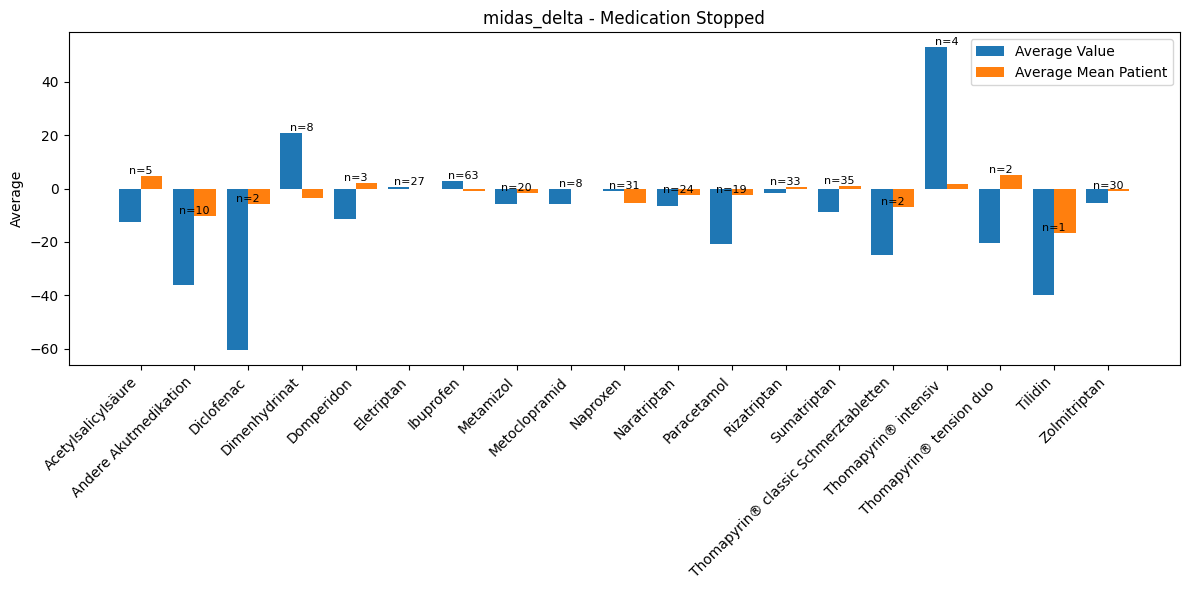

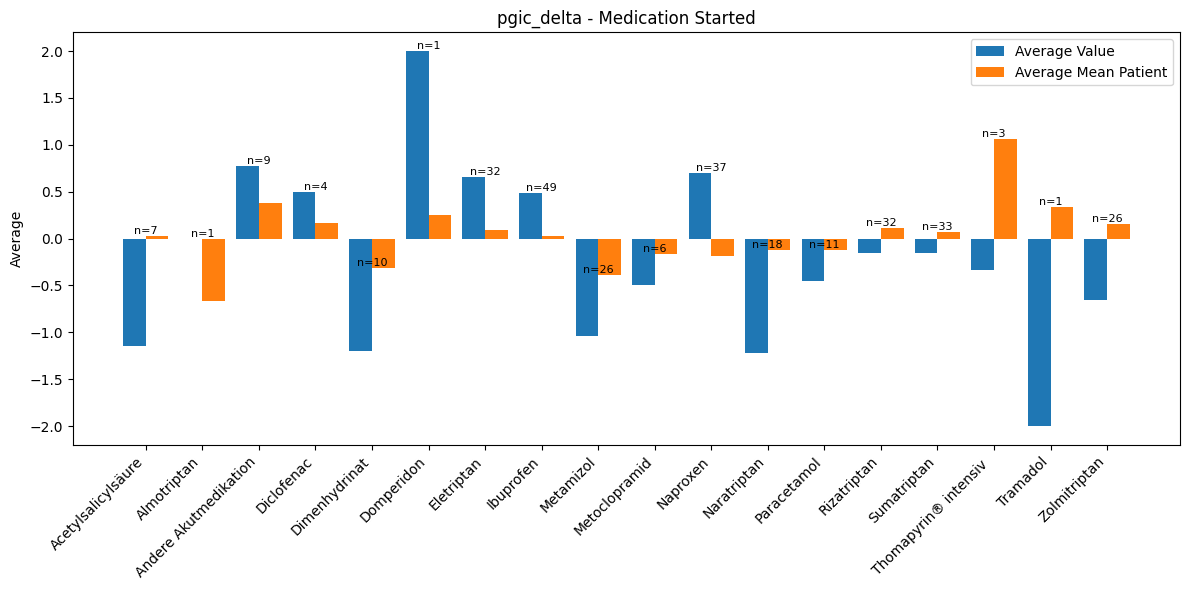

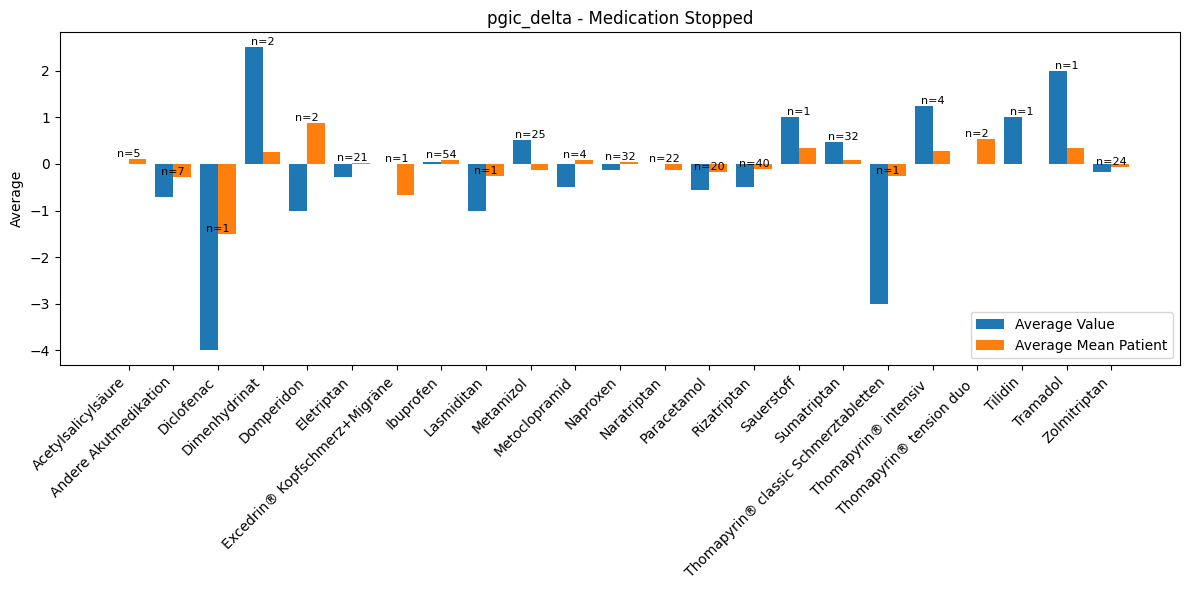

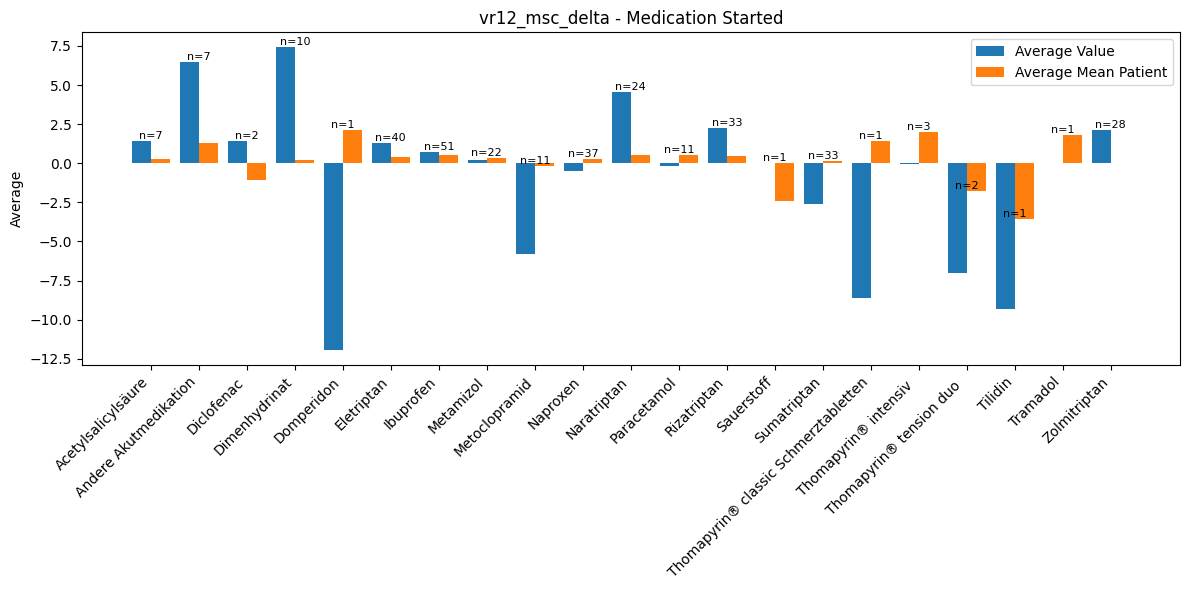

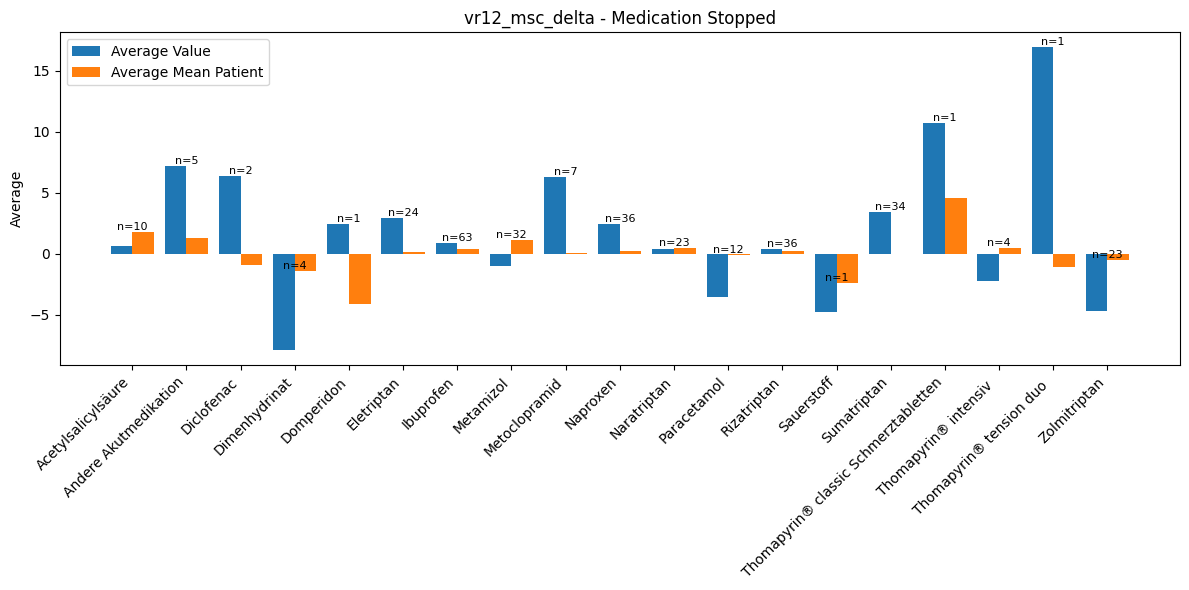

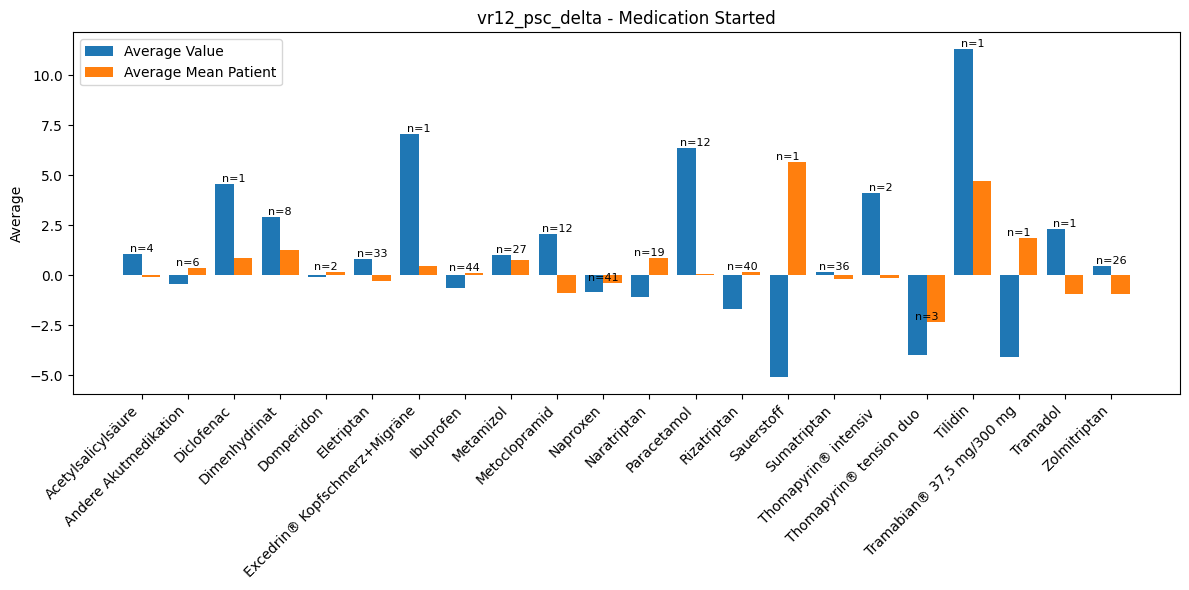

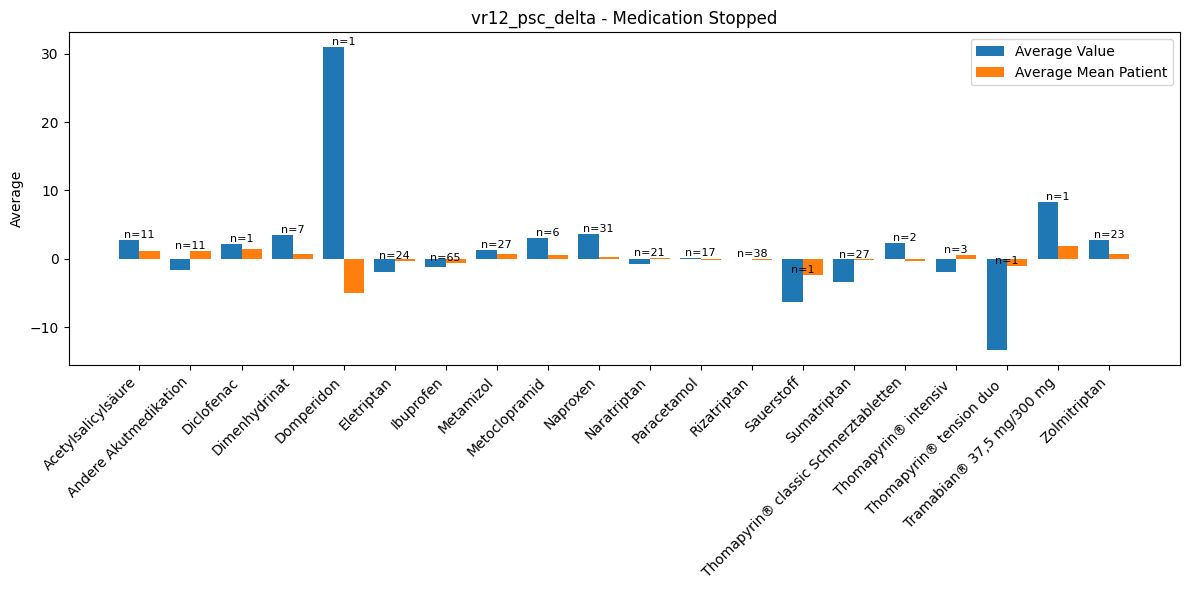

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(events)

rows = []

for action_col, action_name in [
    ("med_started", "Started"),
    ("med_stopped", "Stopped")
]:
    for _, row in df.iterrows():
        meds = row[action_col]

        if meds is None:
            continue

        if not isinstance(meds, (list, tuple, set)):
            meds = [meds]

        for med in meds:
            rows.append({
                "score": row["score"],
                "medication": med,
                "action": action_name,
                "value": row["value"],
                "mean_patient": row["mean_patient"],
            })

plot_df = pd.DataFrame(rows)

agg = (
    plot_df
    .groupby(["score", "medication", "action"])
    .agg(
        avg_value=("value", "mean"),
        avg_mean_patient=("mean_patient", "mean"),
        count=("value", "count"),
    )
    .reset_index()
)

for score in sorted(agg["score"].unique()):

    for action in ["Started", "Stopped"]:

        plot_df = agg[
            (agg["score"] == score)
            & (agg["action"] == action)
            ].copy()

        if plot_df.empty:
            continue

        x = np.arange(len(plot_df))
        width = 0.4

        plt.figure(figsize=(12, 6))

        plt.bar(
            x - width / 2,
            plot_df["avg_value"],
            width,
            label="Average Value"
        )

        plt.bar(
            x + width / 2,
            plot_df["avg_mean_patient"],
            width,
            label="Average Mean Patient"
        )

        plt.xticks(
            x,
            plot_df["medication"],
            rotation=45,
            ha="right"
        )


        for i, (_, row) in enumerate(plot_df.iterrows()):
            ymax = max(
                row["avg_value"],
                row["avg_mean_patient"]
            )

            plt.text(
                i,
                ymax,
                f"n={row['count']}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        plt.title(f"{score} - Medication {action}")
        plt.ylabel("Average")
        plt.legend()
        plt.tight_layout()
        plt.show()